In [44]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_rtl_layer(path, nfrac):
    raw = np.loadtxt(path, delimiter=',')
    flat = raw.flatten()
    return flat / (2 ** nfrac)

def load_ref_layer(path):
    return np.loadtxt(path, delimiter=',')

def rtl_path(test_num, suffix):
    return f"/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/populated_traces/rtl_{test_num}_{suffix}.csv"

def hls_path(test_num, suffix):
    return f"/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/traces/hls4ml_{test_num}_{suffix}.csv"

def keras_path(test_num, suffix):
    return f"/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/traces/keras_{test_num}_{suffix}.csv"

def extract_top_level_util(file, top_names=("myproject", "rheedGaussianWrapper")):
    with open(file) as f:
        text = f.read()
    pattern = (
        r"\|\s*(" + "|".join(top_names) + r")\s*\|\s*\(top\)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|"
        r"\s*(\d+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|"
    )
    m = re.search(pattern, text)
    if m:
        return {
            "Total LUTs": int(m.group(2)), "FFs": int(m.group(6)),
            "RAMB36": int(m.group(7)), "RAMB18": int(m.group(8)), "DSP48": int(m.group(10)),
        }
    return None

def extract_util_percent(file, resources=("CLB LUTs", "CLB Registers", "Block RAM Tile", "DSPs")):
    with open(file) as f:
        text = f.read()
    out = {}
    for r in resources:
        m = re.search(re.escape(r) + r"\s*\|\s*(\d+)\s*\|\s*\d*\s*\|\s*\d*\s*\|\s*(\d+)\s*\|\s*([\d.]+)", text)
        if m:
            out[r] = {"used": int(m.group(1)), "available": int(m.group(2)), "percent": float(m.group(3))}
    return out


def extract_timing_summary(file):
    with open(file) as f:
        text = f.read()
    m = re.search(
        r"WNS\(ns\)\s+TNS\(ns\).*?\n\s*-+\s+-+.*?\n\s*(-?\d+\.\d+)\s+(-?\d+\.\d+)",
        text, re.DOTALL
    )
    if m:
        return {"WNS": float(m.group(1)), "TNS": float(m.group(2))}
    return None

In [45]:
# Handmade RTL vs HLS4ML Summary Results
# Comparison of resource utilization, timing, latency, and accuracy (vs. Keras ground truth) at bitwidth = 8
# Both designs synthesized at a common 10ns (100MHz) clock target.

In [46]:
rows = []
for idx in range(15):
    label = f"populated{idx}"
    rtl_final = load_rtl_layer(rtl_path(label, "final"), 5)
    hls = load_ref_layer(hls_path(label, "q_dense_2"))
    keras = load_ref_layer(keras_path(label, "q_dense_2"))
    rows.append({
        "image": idx,
        "keras_vs_rtl": np.abs(keras - rtl_final).mean(),
        "keras_vs_hls": np.abs(keras - hls).mean(),
    })
df = pd.DataFrame(rows)
print(df.to_string(index=False))
print(f"\nMean RTL error vs Keras:    {df['keras_vs_rtl'].mean():.4f}")
print(f"Mean HLS4ML error vs Keras: {df['keras_vs_hls'].mean():.4f}")

 image  keras_vs_rtl  keras_vs_hls
     0      0.060937      0.062109
     1      0.103320      0.144531
     2      0.104688      0.141992
     3      0.087012      0.108105
     4      0.112793      0.175293
     5      0.037695      0.104297
     6      0.070508      0.075391
     7      0.131055      0.049414
     8      0.023145      0.083301
     9      0.067969      0.134570
    10      0.097656      0.140820
    11      0.045312      0.098047
    12      0.035449      0.113184
    13      0.085547      0.051953
    14      0.028516      0.090430

Mean RTL error vs Keras:    0.0728
Mean HLS4ML error vs Keras: 0.1049


In [47]:
handmade_util = extract_top_level_util("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/handmade_reports/gaussian_handmade_util.rpt")
hls_util = extract_top_level_util("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/hls4ml_reports_new/gaussian_hls4ml_util.rpt")

handmade_timing = extract_timing_summary("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/handmade_reports/gaussian_handmade_timing.rpt")
hls_timing = extract_timing_summary("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/hls4ml_reports_new/gaussian_hls4ml_timing.rpt")

print("Handmade:", handmade_util, handmade_timing)
print("HLS4ML:  ", hls_util, hls_timing)



Handmade: {'Total LUTs': 20076, 'FFs': 6657, 'RAMB36': 0, 'RAMB18': 0, 'DSP48': 0} {'WNS': 1.174, 'TNS': 0.0}
HLS4ML:   {'Total LUTs': 24618, 'FFs': 15650, 'RAMB36': 18, 'RAMB18': 56, 'DSP48': 0} {'WNS': 2.669, 'TNS': 0.0}


In [48]:
# KU035 device capacity 
# Xilinx datasheet specs: https://docs.amd.com/api/khub/documents/dGU6Y~1b8XPqDFk5ulti6g/content
# Table 7
DEVICE_CAPACITY = {
    "Total LUTs": 203128,
    "FFs": 406256,
    "RAMB36": 540,
    "DSP48": 1700,
}

def compute_percent(util_dict, capacity=DEVICE_CAPACITY):
    return {k: (util_dict[k] / capacity[k] * 100) for k in capacity if k in util_dict}

handmade_pct = compute_percent(handmade_util)
hls_pct = compute_percent(hls_util)
print("Handmade %:", handmade_pct)
print("HLS4ML %:  ", hls_pct)

Handmade %: {'Total LUTs': 9.88342326021031, 'FFs': 1.6386219526603913, 'RAMB36': 0.0, 'DSP48': 0.0}
HLS4ML %:   {'Total LUTs': 12.119451774250718, 'FFs': 3.852250797526683, 'RAMB36': 3.3333333333333335, 'DSP48': 0.0}


In [49]:
summary = pd.DataFrame([
    {
        "Design": "Handmade RTL", "Bits": 8,
        **handmade_util, "WNS @10ns (ns)": handmade_timing["WNS"],
        "Latency (cycles)": 19225, "Latency @10ns (µs)": 19225*10/1000,
        "Mean Abs Error vs Keras": df["keras_vs_rtl"].mean(),
    },
    {
        "Design": "HLS4ML", "Bits": 8,
        **hls_util, "WNS @10ns (ns)": hls_timing["WNS"],
        "Latency (cycles)": "34571-34577 (HLS est.)", "Latency @5ns target (µs)": (34571*5)/1000,
        "Mean Abs Error vs Keras": df["keras_vs_hls"].mean(),
    },
])
summary

,Design,Bits,Total LUTs,FFs,RAMB36,RAMB18,DSP48,WNS @10ns (ns),Latency (cycles),Latency @10ns (µs),Mean Abs Error vs Keras,Latency @5ns target (µs)
0,Handmade RTL,8,20076,6657,0,0,0,1.174,19225,192.25,0.072773,NaN
1,HLS4ML,8,24618,15650,18,56,0,2.669,34571-34577 (HLS est.),NaN,0.104896,172.855


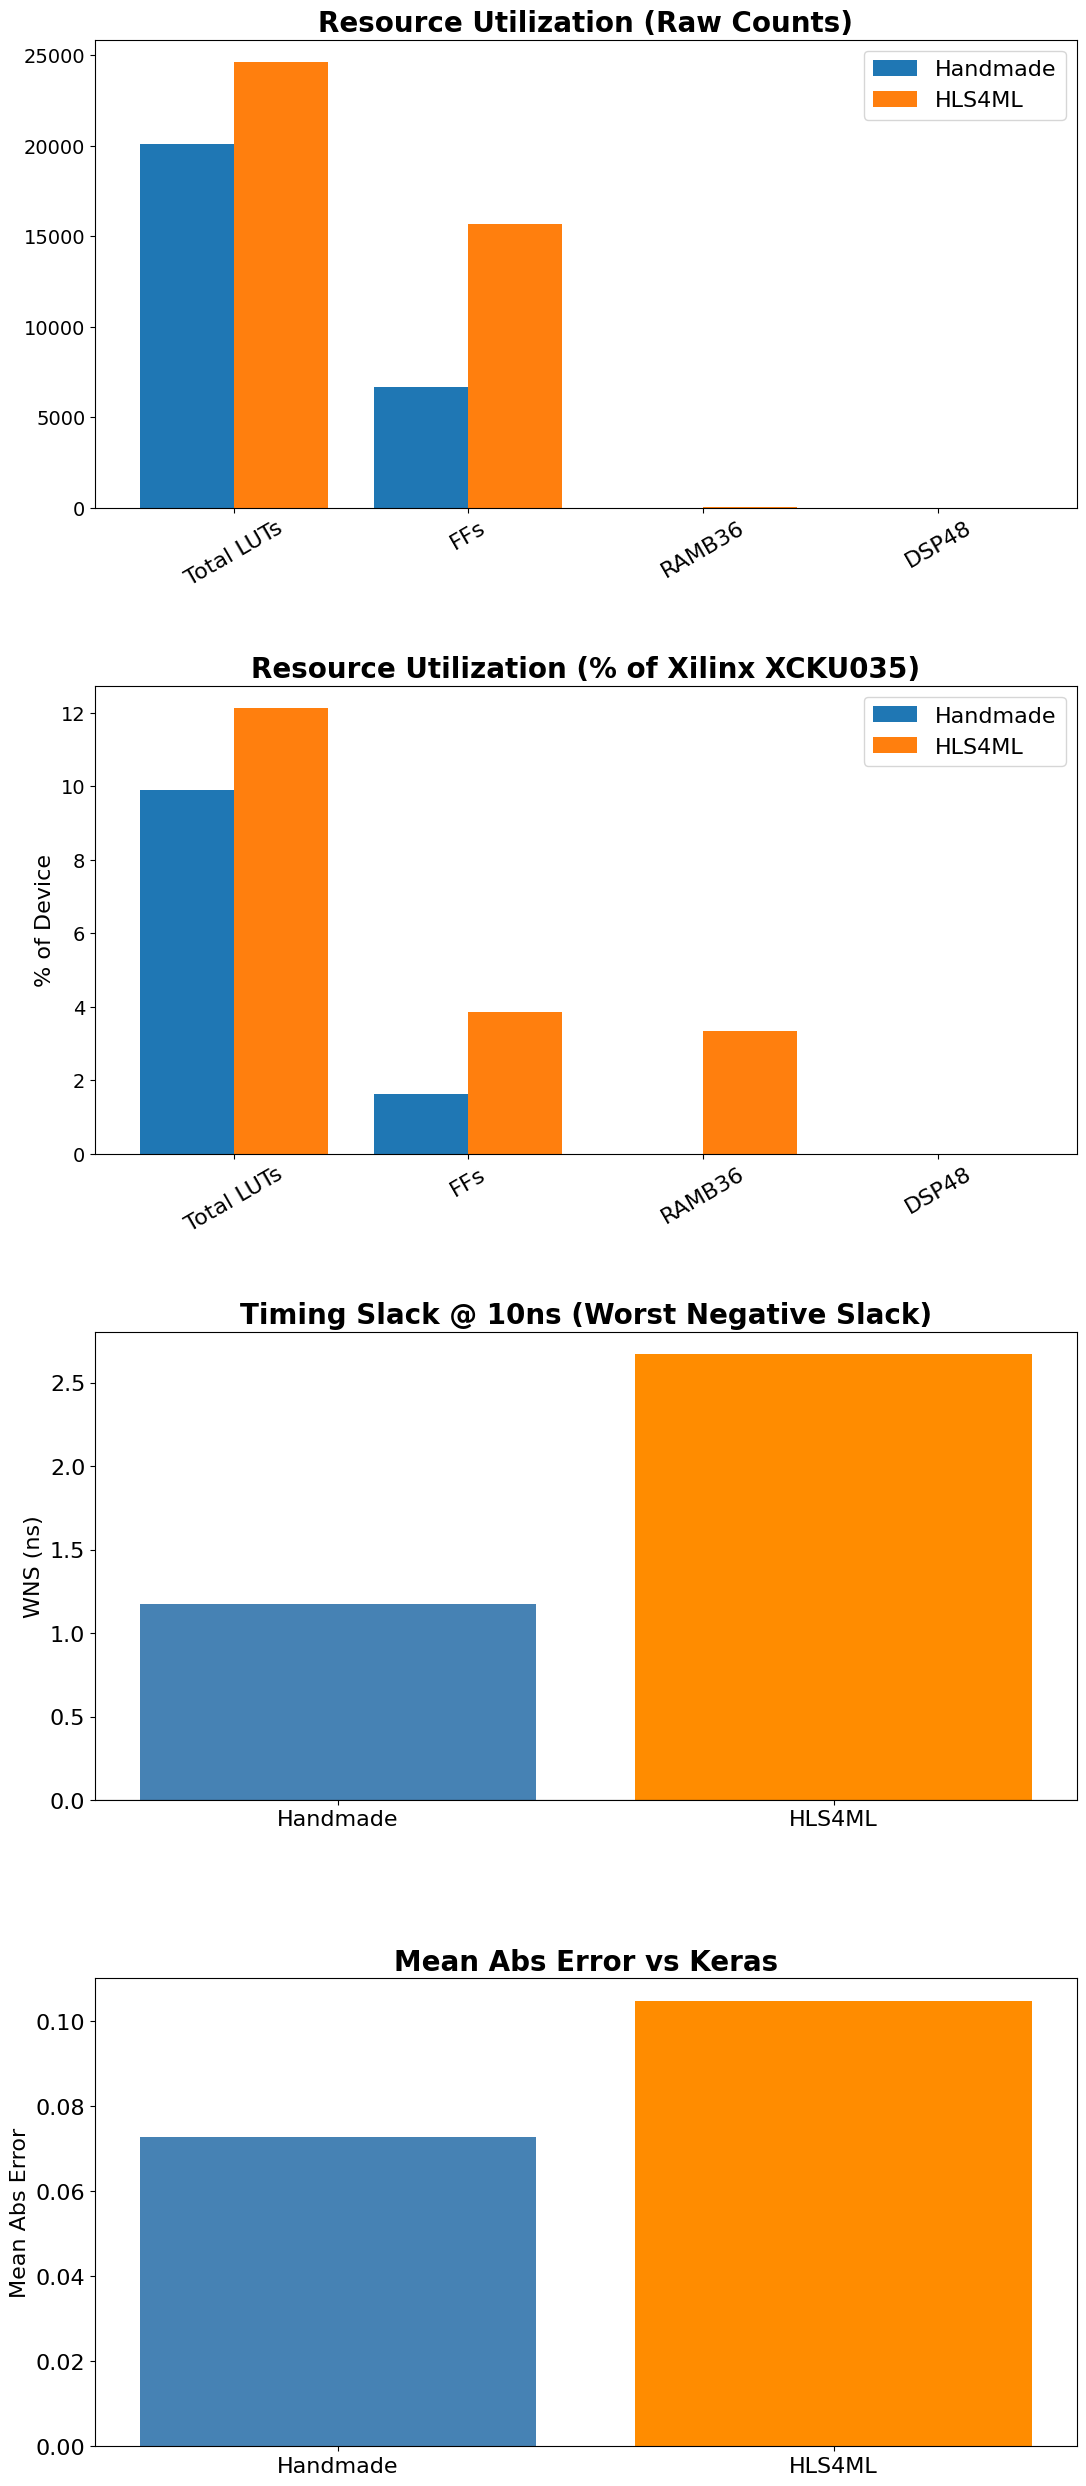

In [ ]:
plt.rcParams.update({'font.size': 16})

fig, axes = plt.subplots(4, 1, figsize=(12, 26))

metrics = ["Total LUTs", "FFs", "RAMB36", "DSP48"]
x = np.arange(len(metrics))

# panel 1: raw resource counts
axes[0].bar(x-0.2, [handmade_util[m] for m in metrics], 0.4, label="Handmade")
axes[0].bar(x+0.2, [hls_util[m] for m in metrics], 0.4, label="HLS4ML")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=30, fontsize=16)
axes[0].set_title("Resource Utilization (Raw Counts)", fontsize=20, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=14)
axes[0].legend(fontsize=16)

# panel 2: percent utilization of device (XCKU035 capacity)
axes[1].bar(x-0.2, [handmade_pct[m] for m in metrics], 0.4, label="Handmade")
axes[1].bar(x+0.2, [hls_pct[m] for m in metrics], 0.4, label="HLS4ML")
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, rotation=30, fontsize=16)
axes[1].set_title("Resource Utilization (% of Xilinx XCKU035)", fontsize=20, fontweight='bold')
axes[1].set_ylabel("% of Device", fontsize=16)
axes[1].tick_params(axis='y', labelsize=14)
axes[1].legend(fontsize=16)

# panel 3: timing
axes[2].bar(["Handmade","HLS4ML"], [handmade_timing["WNS"], hls_timing["WNS"]], color=["steelblue","darkorange"])
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_title("Timing Slack @ 10ns (Worst Negative Slack)", fontsize=20, fontweight='bold')
axes[2].set_ylabel("WNS (ns)", fontsize=16)
axes[2].tick_params(axis='both', labelsize=16)

# panel 4: accuracy
axes[3].bar(["Handmade","HLS4ML"], [df["keras_vs_rtl"].mean(), df["keras_vs_hls"].mean()], color=["steelblue","darkorange"])
axes[3].set_title("Mean Abs Error vs Keras", fontsize=20, fontweight='bold')
axes[3].set_ylabel("Mean Abs Error", fontsize=16)
axes[3].tick_params(axis='both', labelsize=16)

plt.tight_layout(pad=3.0)
plt.show()